In [70]:
import numpy as np
from matplotlib import pyplot as plt

from koala.voronization import generate_lattice
from koala.pointsets import uniform
from koala.graph_utils import lloyd_relaxation
from koala import plotting as kplt


In [103]:
points  = uniform(500)
lattice = generate_lattice(points)
lattice = lloyd_relaxation(lattice, 50)
 


<AxesSubplot:>

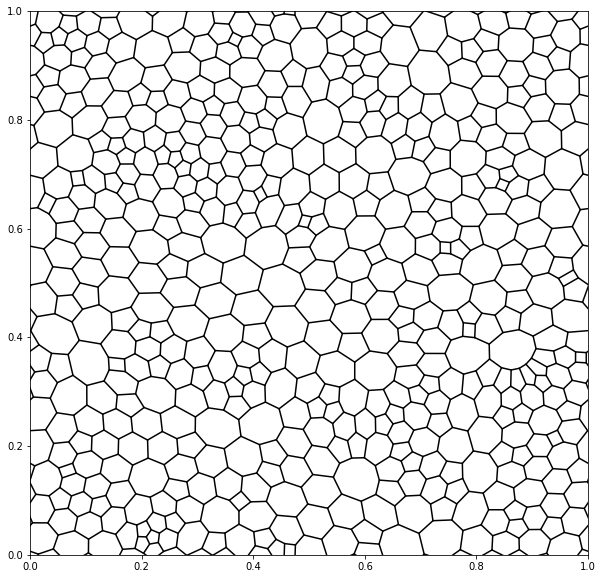

In [104]:
fig, ax = plt.subplots(figsize = (10,10))
kplt.plot_edges(lattice)

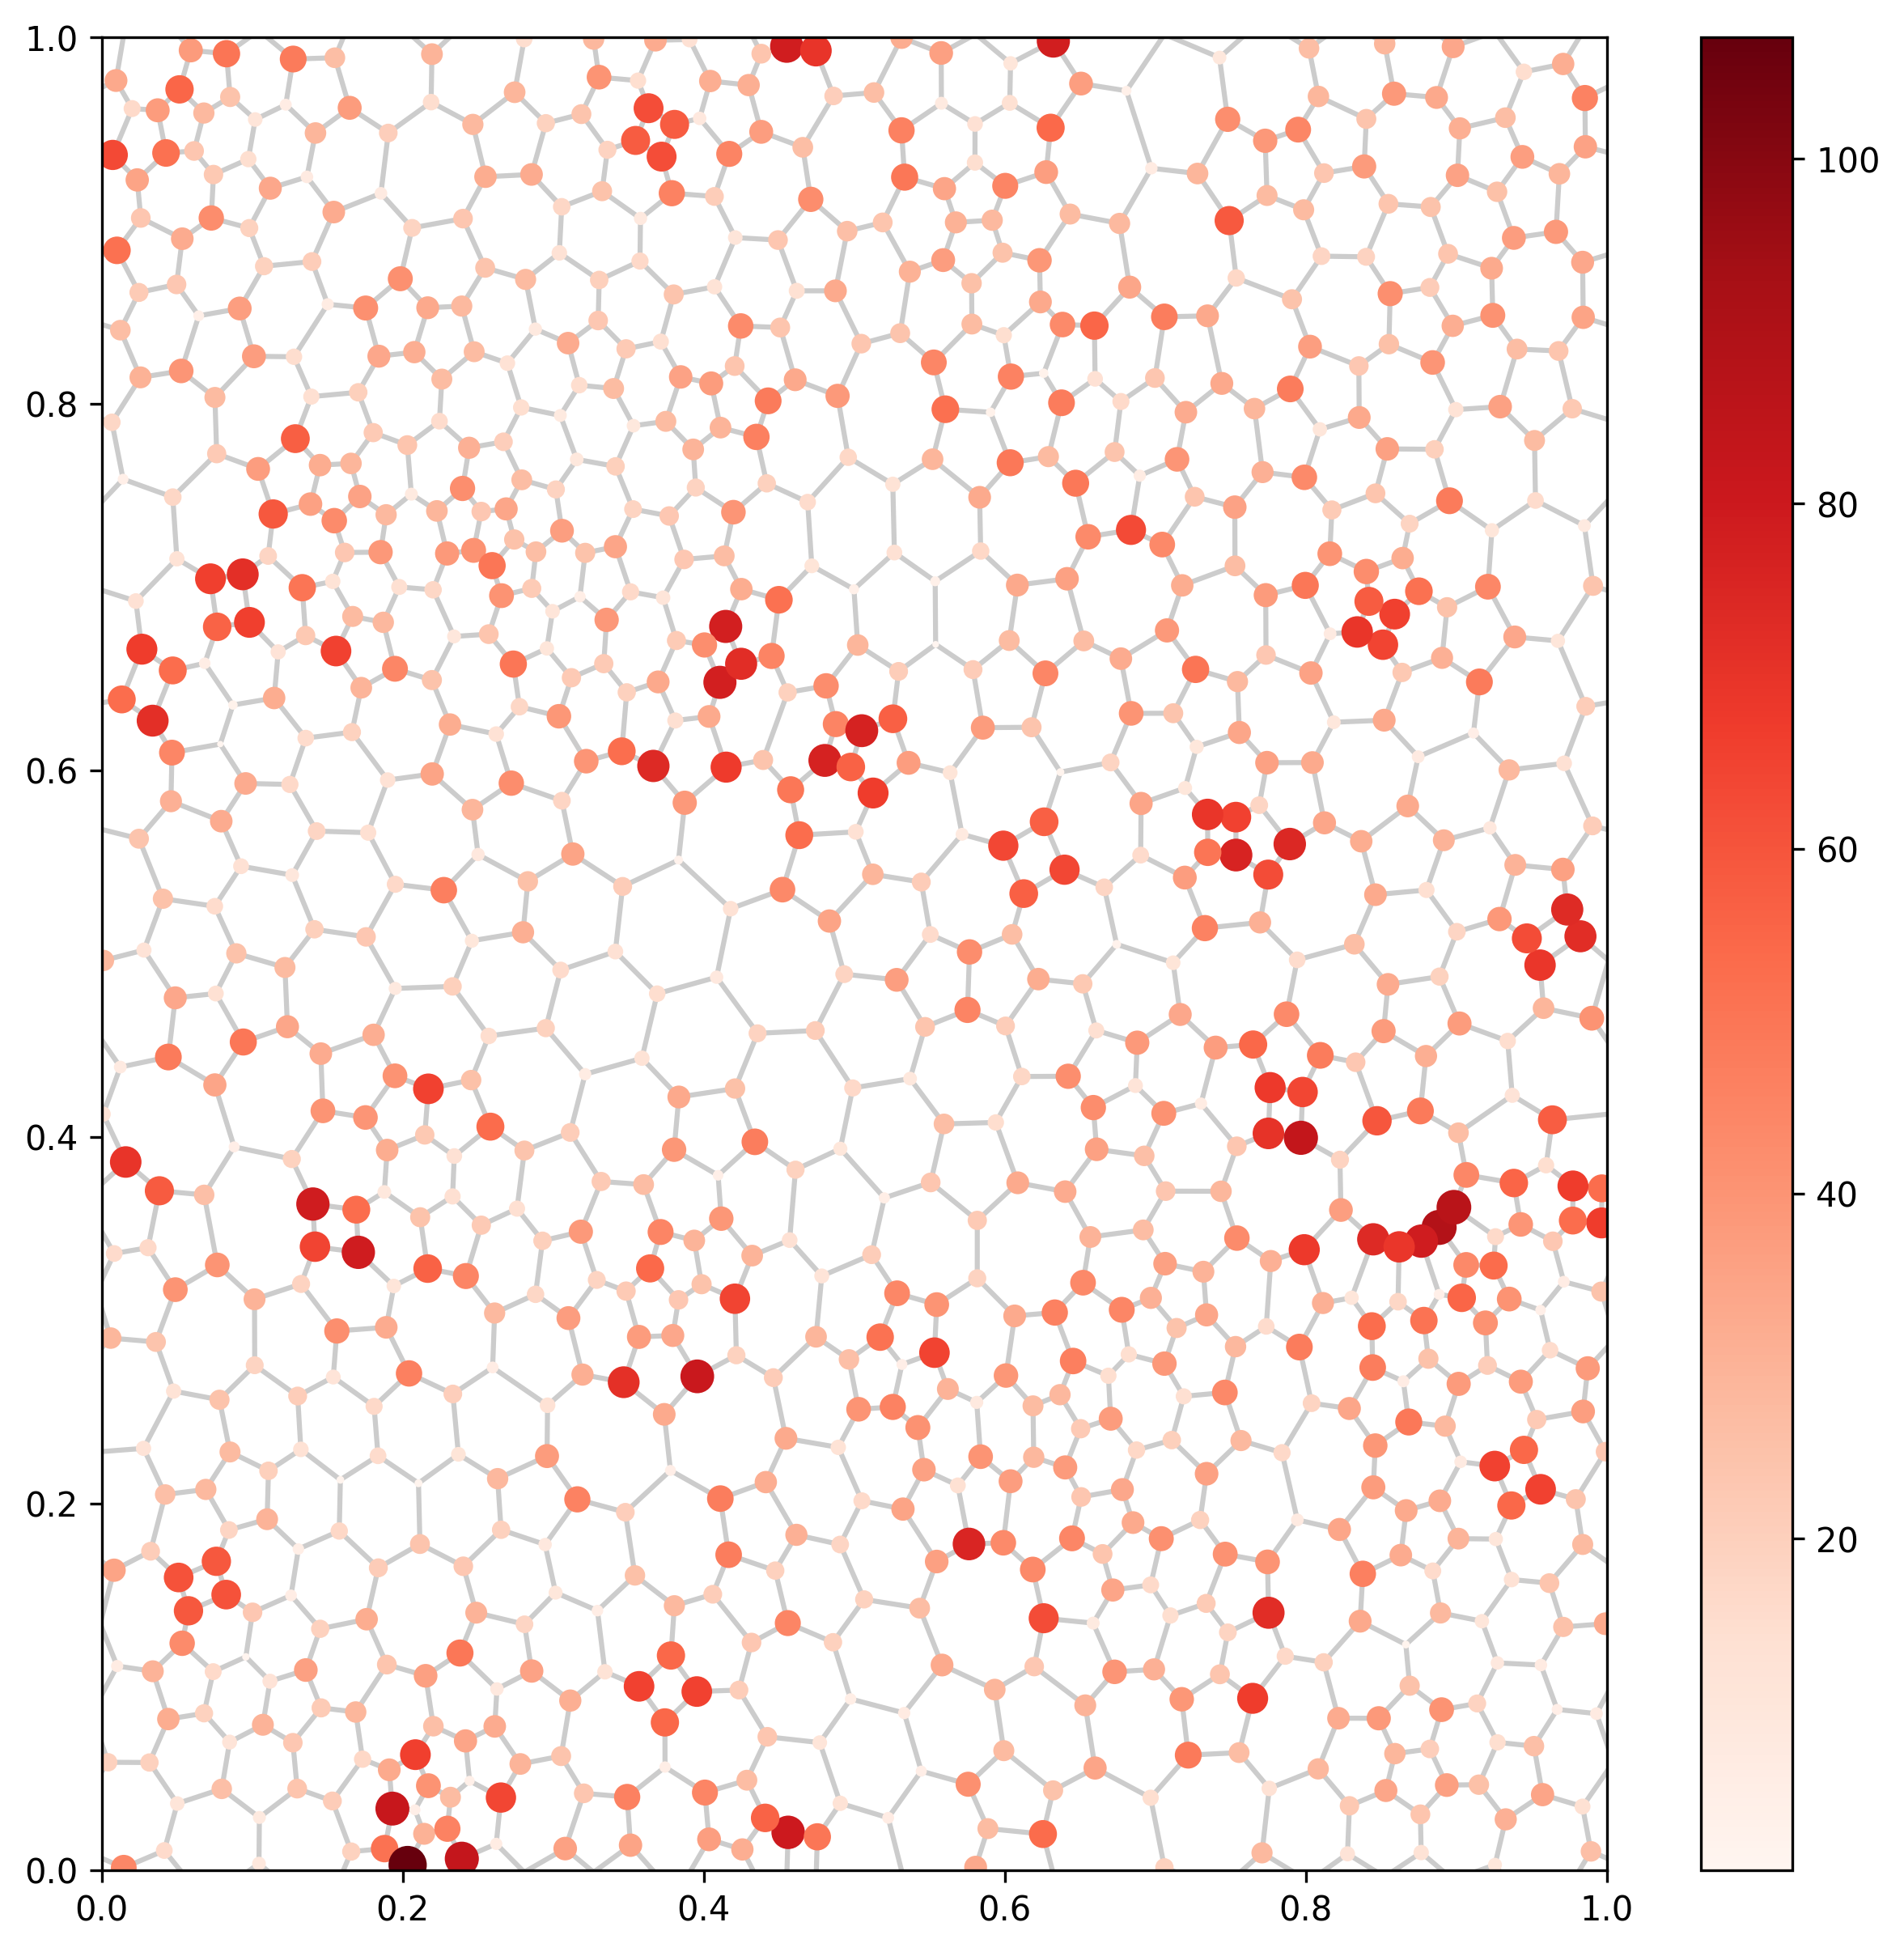

In [108]:
# find all angles
lattice.vertices.adjacent_edges

adjacent_vectors = np.array([lattice.edges.vectors[x] for x in lattice.vertices.adjacent_edges
])
adjacent_vectors.shape
angles = np.arctan2(adjacent_vectors[:,:,0], adjacent_vectors[:,:,1])
angle_differences = (angles - np.roll(angles,1,1))%(np.pi) 
angle_differences = 180*angle_differences/np.pi

x = angle_differences-120
divergences = np.abs(x).sum(1)


fig, ax = plt.subplots(figsize = (10,10), dpi=300)
plt.scatter(lattice.vertices.positions[:,0], lattice.vertices.positions[:,1], c = divergences, s = divergences, cmap = 'Reds',zorder=2)
kplt.plot_edges(lattice, alpha = 0.2,zorder=1)
plt.colorbar()